# String Creation and Accessing

Strings are created through assignment operator using **single**, **double**, or **triple** quotes: 'hello', "hello", """hello""".

The built-in Python function `len()` works with string as well.

In [ ]:
import sys
from pathlib import Path

# Find project root by looking for _config.yml
current = Path.cwd()
for parent in [current, *current.parents]:
    if (parent / '_config.yml').exists():
        project_root = parent
        break
else:
    project_root = Path.cwd().parent.parent

# Add project root to path
sys.path.insert(0, str(project_root))

# Import shared teaching helpers and cell magics
from shared import thinkpython, diagram, jupyturtle, structshape
from shared.download import download


In [2]:
s = 'supercalifragilisticexpialidocious'

print(type(s))

n = len(s)
print(n)

<class 'str'>
34


Single and double quotes are interchangeable for single-line strings. Triple quotes are used for multi-line strings or strings that contain both single and double quotes.

In [3]:
s1 = 'Hello, world!'
s2 = "Hello, world!"
s3 = """This is
a multi-line
string."""

print(s1)
print(s2)
print(s3)

Hello, world!
Hello, world!
This is
a multi-line
string.


## Escape Sequences and Raw Strings

Inside a string, a backslash `\` introduces an **escape sequence** — a two-character combination that represents a special character:

| Escape Sequence | Meaning | Example output |
|---|---|---|
| `\n` | Newline | moves to the next line |
| `\t` | Tab | inserts a horizontal tab |
| `\\` | Backslash | a literal `\` |
| `\"` | Double quote | `"` inside a double-quoted string |
| `\'` | Single quote | `'` inside a single-quoted string |

A **raw string** is prefixed with `r` (or `R`) and treats backslashes as literal characters — no escape sequences are processed. Raw strings are especially useful for regular expression patterns and file paths.

In [4]:
print("line1\nline2")       # newline
print("col1\tcol2")         # tab
print("C:\\Users\\ty")      # literal backslashes
print(r"C:\Users\ty")       # raw string — same result, easier to read


line1
line2
col1	col2
C:\Users\ty
C:\Users\ty


In [5]:
### EXERCISE: Escape Sequences and Raw Strings
# Difficulty: Basic
# 1. Print two words on two lines using \n
# 2. Print two values separated by a tab using \t
# 3. Print a Windows path using a raw string
### Your code starts here:


### Your code ends here.

In [6]:
# Solution
print("apple\nbanana")
print("score\t95")
print(r"C:\Users\alice\data")

apple
banana
score	95
C:\Users\alice\data


## Indexing and Slicing

Strings are **sequences**, meaning each character has a numbered position called an **index**. Python uses zero-based indexing: the first character is at index `0`, the second at index `1`, and so on. Negative indices count from the end of the string.

### String Indexing

As a sequence type, the expression in brackets is an **index**, so called because it *indicates* which character in the sequence to select. String indexing is `0`-based.

In [7]:
fruit = "banana"
print(fruit[0])

b


You can select a character from a string with the **bracket operator**.

In [8]:
s = 'Python'

print(s[0])    # 'P'  — first character
print(s[1])    # 'y'  — second character
print(s[-1])   # 'n'  — last character
print(s[-2])   # 'o'  — second to last

P
y
n
o


As a reminder, the last letter of a string is the length of the string minus 1. If you use `len()` to access the last element of the sequence you get an `IndexError` (**`string index out of range`**) because there is no element there to be accessed: **0-based indexing**. 

Also because of 0-based indexing, to get the last character, you have to subtract `1` from `n` (**n-1**).

In [9]:
fruit = 'banana'
n = len(fruit)

In [ ]:
%%expect IndexError
fruit[n]


In [11]:
fruit[n-1]

'a'

Often forgotten, there's an easier way to access the last element of a sequence: negative indexing, which counts backward from the end. The index `-1` selects the last letter, `-2` selects the second to last, and so on.

In [12]:
fruit[-1]

'a'

The index in brackets can be a variable.
Or an expression that contains variables and operators.

In [13]:
i = 1
print(fruit[i])
print(fruit[i+1])

for i in range(len(fruit)):
    print(fruit[i], end=' ')


a
n
b a n a n a 

Just like lists and tuples, the value of the **index** has to be an **integer** -- otherwise you get a `TypeError`.

In [ ]:
%%expect TypeError
fruit[1.5]


It is tempting to use the `[]` operator on the left side of an
assignment, with the intention of changing a character in a string. 

The result is a `TypeError`. In the error message, the object is the string and the "item" is the character we tried to assign. 

The reason for this error is that strings are **immutable**, which means you can't change an existing string. 

In [15]:
greeting = 'hello, world'

In [ ]:
%%expect TypeError
greeting[0] = 'J'


The best you can do is create a new string that is a variation of the original.

In [17]:
new_greeting = 'J' + greeting[1:]     ### "+" is concatenate here
new_greeting

'Jello, world'

This example concatenates a new first letter onto a slice of `greeting`.
It has no effect on the original string.

In [18]:
greeting

'hello, world'

### Slicing Strings

Just like lists and tuples, a segment of a string is called a **slice**. Selecting a slice is similar to selecting a character. The general syntax of slicing is the same as lists and tuple:

```python 
sequence[start:stop:step]
``` 
Also, the parameters are start-inclusive and stop-exclusive.

- `start` — index to begin at (inclusive, default `0`)
- `stop` — index to end at (exclusive, default end of string)
- `step` — how many characters to skip (default `1`)

In [19]:
fruit = 'banana'
fruit[0:3]

'ban'

The operator `[m:n]` returns the part of the string from the `m`th character to the `n`th character, including the first but **excluding** the second. This behavior is counterintuitive, but it might help to imagine the indices pointing *between* the characters, as in this figure:

In [20]:
from shared.diagram import make_binding, Element, Value

binding = make_binding("fruit", ' b a n a n a ')
elements = [Element(Value(i), None) for i in range(7)]

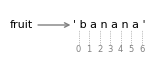

In [21]:
import matplotlib.pyplot as plt
from shared.diagram import diagram, adjust
from matplotlib.transforms import Bbox

width, height, x, y = [1.35, 0.54, 0.23, 0.39]

ax = diagram(width, height)
bbox = binding.draw(ax, x, y)
bboxes = [bbox]

def draw_elts(x, y, elements):
    for elt in elements:
        bbox = elt.draw(ax, x, y, draw_value=False)
        bboxes.append(bbox)

        x1 = (bbox.xmin + bbox.xmax) / 2
        y1 = bbox.ymax + 0.02
        y2 = y1 + 0.14
        handle = plt.plot([x1, x1], [y1, y2], ':', lw=0.5, color='gray')
        x += 0.105
    
draw_elts(x + 0.48, y - 0.25, elements)
bbox = Bbox.union(bboxes)
# adjust(x, y, bbox)

For example, the slice `[3:6]` selects the letters `ana`, which means that `6` is **legal** as part of a **slice**, but **not** **legal** as an **index**.

Also, 
- if you omit the first index, the slice starts at the beginning of the string.
- if you omit the second index, the slice goes to the end of the string:

In [22]:
s = 'Hello, world!'

print(s[0:5])    # 'Hello'   — characters 0 through 4
print(s[7:])     # 'world!'  — from index 7 to end
print(s[:5])     # 'Hello'   — from start to index 4
print(s[::2])    # every other character
print(s[::-1])   ### 'reversed string' ###

Hello
world!
Hello
Hlo ol!
!dlrow ,olleH


If the first index is greater than or equal to the second, the result is an **empty string**, represented by two quotation marks. An empty string contains no characters and has length 0.

In [23]:
print(f"len(fruit[3:3]): {len(fruit[3:3])}")
print(f"Type of fruit[3:3]: {type(fruit[3:3])}")
fruit[3:3]

len(fruit[3:3]): 0
Type of fruit[3:3]: <class 'str'>


''

Continuing this example, what do you think `fruit[:]` means? Try it and
see.

In [24]:
fruit[:]

'banana'

To practice your slicing skills, play these in your head with string "banana", which may not be as easy as you think.

In [25]:
fruit[0:-1]                     
fruit[-2:]                      
fruit[0:-1:2]                   

# print(fruit[0:-1])              ### all but the last letter: banan
# print(fruit[-2:])               ### the last two letters: na
# print(fruit[0:-1:2])            ### step is 2, so you get bnn

'bnn'

In [26]:
### EXERCISE: Indexing and Slicing
# Difficulty: Basic
text = 'superpython'
# 1. Print the first character
# 2. Print the last character using negative indexing
# 3. Print every second character
# 4. Print the reversed string
### Your code starts here:


### Your code ends here.

In [27]:
# Solution
text = 'superpython'
print(text[0])
print(text[-1])
print(text[::2])
print(text[::-1])

s
n
spryhn
nohtyprepus


## Concatenation and Repetition

The `+` operator joins two strings together (**concatenation**). The `*` operator repeats a string a given number of times (**repetition**).

In [28]:
first = 'Hello'
last  = 'World'

# Concatenation
greeting = first + ', ' + last + '!'
print(greeting)        # 'Hello, World!'

# Repetition
line = '* ' * 10
print(line)            # '* * * * * * * * * * '

print('ha' * 3)        # 'hahaha'

Hello, World!
* * * * * * * * * * 
hahaha


In [29]:
### EXERCISE: Concatenation and Repetition
# Difficulty: Basic
first = 'Alice'
last = 'Bob'
# 1. Build and print: "Alice & Bob" using concatenation
# 2. Print "ha" repeated 4 times
# 3. Create a divider of 20 dashes and print it
### Your code starts here:


### Your code ends here.

In [30]:
# Solution
first = 'Alice'
last = 'Bob'
print(first + " & " + last)
print("ha" * 4)
print("-" * 20)

Alice & Bob
hahahaha
--------------------
